In [85]:
import requests
from rdflib import Graph, URIRef, Literal, Namespace
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [86]:
#VIRTUOSO_URL = "http://localhost:8890/sparql-graph-crud"
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI = "http://example.com/Gent-Terneuzen"
USERNAME = "dba"
PASSWORD = "dba"
AUTH  = (USERNAME,PASSWORD)


In [87]:
params = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

In [88]:
LIMIT = 100000 
offset = 0
g = Graph()
time_series_data = [] 
df = pd.DataFrame()

# Identifying unique sensors

In [89]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT  DISTINCT ?sensor
    WHERE {{ 
        GRAPH <{GRAPH_URI}> {{ 
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }} 
    }} 
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
        print(f"Error: {res.status_code}")
        print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data = res.json()
bindings = data['results']['bindings']

for row in bindings:
    # Extract the URI string and add it to the set
    sensor_uri = row['sensor']['value']
    sensor_set.add(sensor_uri)

print(f"Added {len(sensor_set)}9 unique sensors to the set.")
print("Sensors:", sensor_set)


Unique sensors identified successfully!
Added 89 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289439042', 'http://example.com/waterinfo/289427042', 'http://example.com/waterinfo/289421042', 'http://example.com/waterinfo/289433042', 'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289435042'}


In [ ]:
print("Fetching date-value pairs...")
query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT ?time ?value ?sensor
    WHERE {{ 
        GRAPH <{GRAPH_URI}> {{ 
            ?obs a sosa:Observation ;
                 sosa:resultTime ?time ;
                 sosa:hasSimpleResult ?value ;
                 sosa:madeBySensor ?sensor .
        }} 
    }} 
    """
res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})


if res.status_code != 200:
        print(f"Error: {res.status_code}")
        print("Response:", res.text)
else:
    print("Data fetched successfully!")

bindings = res.json()['results']['bindings']

for row in bindings:
    df = df.append({'time': row['time']['value'], 'value': float(row['value']['value']), 'sensor': row['sensor']['value']}, ignore_index=True)

# df = pd.DataFrame([
#         {'time': row['time']['value'], 'value': float(row['value']['value'])} 
#         for row in bindings
#     ])

df['time'] = pd.to_datetime(df['time'])
print("Finished!")

Fetching date-value pairs...
Data fetched successfully!
Finished!


In [74]:
#print(df.head()) # Prints the first 5 rows
print(df['value'])

0         11200.20
1         11198.50
2          9346.65
3          9778.39
4          9045.88
            ...   
751105     5213.48
751106     5232.33
751107     5305.69
751108     5295.89
751109     5344.28
Name: value, Length: 751110, dtype: float64


# ARIMA models

## Auto correlation

In [75]:
# autocorr(lag=k) returns Pearson correlation of series with itself shifted by k
for lag in [1, 4, 96]:          # lag 1 = 15 min, 4 = 1 hr, 96 = 1 day
    r = df["value"].autocorr(lag=lag)
    print(f"  Autocorrelation at lag {lag:>3} ({lag*15} min): {r:.4f}")

  Autocorrelation at lag   1 (15 min): 0.9984
  Autocorrelation at lag   4 (60 min): 0.9948
  Autocorrelation at lag  96 (1440 min): 0.9653


Lag 1 (0.9984) — a reading is almost perfectly predicted by the reading 15 minutes before it. The series moves very smoothly with almost no sudden jumps.
Lag 4 (0.9948) — still nearly identical 1 hour later. Change is very gradual.
Lag 96 (0.9653) — even a full day later, values are still strongly correlated. There's a clear daily pattern or slow-moving trend in the data.

non-stationary series — the values are drifting slowly over time rather than fluctuating around a fixed mean. 

In [76]:
# Check how differencing changes autocorrelation
diff = df["value"].diff().dropna()

for lag in [1, 4, 96]:
    r = diff.autocorr(lag=lag)
    print(f"After diff — lag {lag:>3} ({lag*15} min): {r:.4f}")

After diff — lag   1 (15 min): -0.0195
After diff — lag   4 (60 min): -0.0251
After diff — lag  96 (1440 min): 0.0429


# Random Forest

In [77]:
df = df.sort_values('time').set_index('time')

# 1. Temporal features (The Cycles)
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter

In [78]:
# 2. Lag features (The Memory)
# 'lag_1' is the reading from 15 mins ago
df['lag_1'] = df['value'].shift(1)
# 'lag_96' is the reading from exactly 24 hours ago (96 * 15 min = 24h)
df['lag_96'] = df['value'].shift(96)

In [79]:
# Drop the rows where lags are NaN (the very beginning of your 3-year span)
df.dropna(inplace=True)

In [81]:
train_size = int(len(df) * 0.85)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train = train.drop(columns=['value'])
y_train = train['value']
X_test = test.drop(columns=['value'])
y_test = test['value']

# Initialize and Train
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get the Output (Predictions)
predictions = rf.predict(X_test)

# See how you did
mae = mean_absolute_error(y_test, predictions)
print(f"On average, the model is off by: {mae:.2f}")

On average, the model is off by: 4549.63


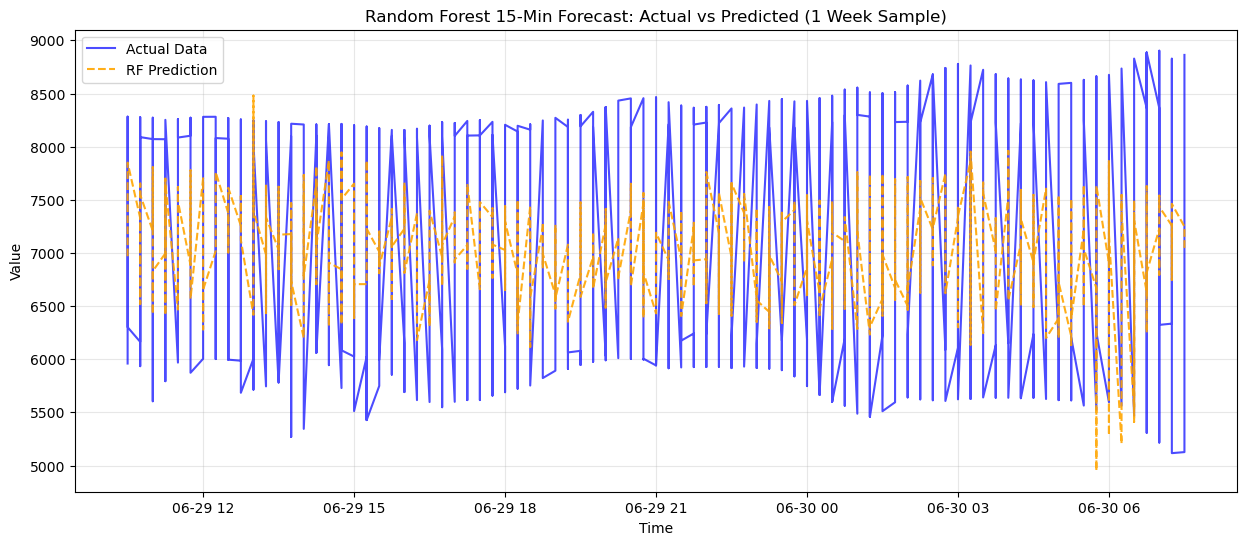

In [82]:
# 1. Create a DataFrame for comparison
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': predictions}, index=y_test.index)

# 2. Select a 1-week window to visualize the 15-min intervals clearly
# (e.g., the first 7 days of your test set)
sample_window = comparison.iloc[:96*7] 

plt.figure(figsize=(15, 6))
plt.plot(sample_window['Actual'], label='Actual Data', alpha=0.7, color='blue')
plt.plot(sample_window['Predicted'], label='RF Prediction', alpha=0.9, color='orange', linestyle='--')

plt.title('Random Forest 15-Min Forecast: Actual vs Predicted (1 Week Sample)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()